# Potato Disease Classification

Dataset credits: https://www.kaggle.com/arjuntejaswi/plant-village

### Import all the Dependencies

In [53]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML
import numpy as np

### Set all the Constants

In [1]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS=3
EPOCHS=50

### Import data into tensorflow dataset object

We will use image_dataset_from_directory api to load all images in tensorflow dataset: https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [4]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [5]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(32, 256, 256, 3)
[1 1 1 0 0 0 0 0 1 1 1 1 0 1 0 1 1 1 0 1 0 1 0 0 1 0 0 1 1 2 0 0]


As you can see above, each element in the dataset is a tuple. First element is a batch of 32 elements of images. Second element is a batch of 32 elements of class labels 

### Visualize some of the images from our dataset

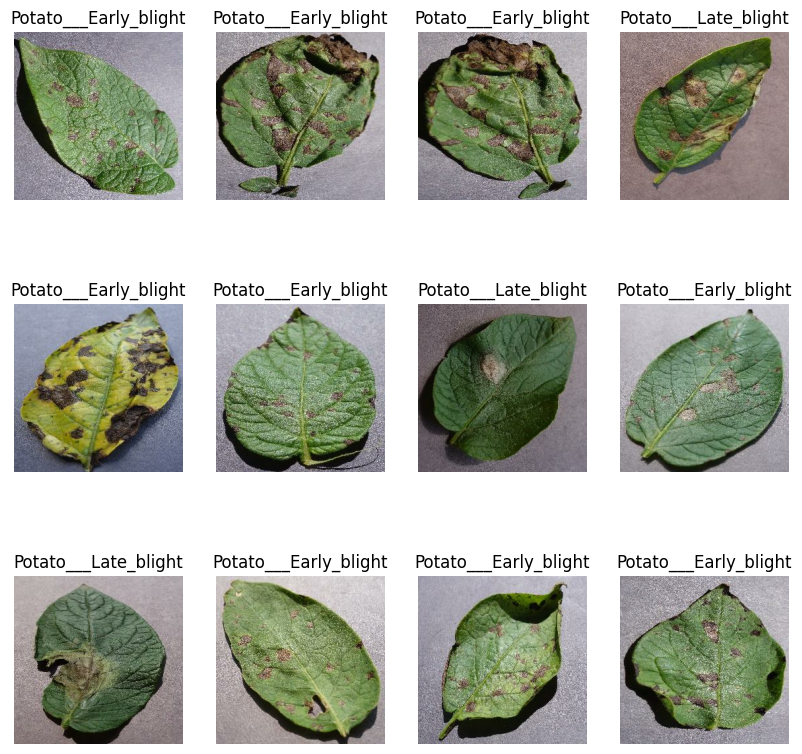

In [6]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

### Function to Split Dataset

Dataset should be bifurcated into 3 subsets, namely:
1. Training: Dataset to be used while training
2. Validation: Dataset to be tested against while training
3. Test: Dataset to be tested against after we trained a model

In [7]:
len(dataset)

68

In [8]:
train_size = 0.8
len(dataset)*train_size

54.400000000000006

In [9]:
train_ds = dataset.take(54)
len(train_ds)

54

In [10]:
test_ds = dataset.skip(54)
len(test_ds)

14

In [11]:
val_size=0.1
len(dataset)*val_size

6.800000000000001

In [12]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [13]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [14]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [15]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [16]:
len(train_ds)

54

In [17]:
len(val_ds)

6

In [19]:
len(test_ds)

8

### Cache, Shuffle, and Prefetch the Dataset

In [18]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

## Building the Model

### Creating a Layer for Resizing and Normalization
Before we feed our images to network, we should be resizing it to the desired size. 
Moreover, to improve model performance, we should normalize the image pixel value (keeping them in range 0 and 1 by dividing by 256).
This should happen while training as well as inference. Hence we can add that as a layer in our Sequential Model.

You might be thinking why do we need to resize (256,256) image to again (256,256). You are right we don't need to but this will be useful when we are done with the training and start using the model for predictions. At that time somone can supply an image that is not (256,256) and this layer will resize it

In [20]:
resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  layers.Rescaling(1./255),
])

### Data Augmentation
Data Augmentation is needed when we have less data, this boosts the accuracy of our model by augmenting the data.

In [22]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
])

### Model Architecture
We use a CNN coupled with a Softmax activation in the output layer. We also add the initial layers for resizing, normalization and Data Augmentation.

**We are going to use convolutional neural network (CNN) here. CNN is popular for image classification tasks. Watch below video to understand fundamentals of CNN**

In [26]:
import tensorflow as tf
from tensorflow.keras import models, layers

# Define your parameters
IMAGE_SIZE = 256
CHANNELS = 3
BATCH_SIZE = 32
n_classes = 3

input_shape_without_batch = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model = models.Sequential([
    # Explicitly set the input shape
    layers.Input(shape=input_shape_without_batch),
    
    # Define preprocessing inline so they build with the correct shape
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255),
    
    # Optional Data Augmentation (uncomment if you use it)
    # layers.RandomFlip("horizontal_and_vertical"),
    # layers.RandomRotation(0.2),
    
    # Convolutional Base
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Dense Head
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

In [27]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_1 (Resizing)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

### Compiling the Model
We use `adam` Optimizer, `SparseCategoricalCrossentropy` for losses, `accuracy` as a metric

In [28]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [29]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=50,
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 29s 475ms/step - accuracy: 0.4774 - loss: 0.9164 - val_accuracy: 0.6406 - val_loss: 0.8643
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 445ms/step - accuracy: 0.6777 - loss: 0.7175 - val_accuracy: 0.7448 - val_loss: 0.5354
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 456ms/step - accuracy: 0.8061 - loss: 0.4353 - val_accuracy: 0.8333 - val_loss: 0.3427
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 468ms/step - accuracy: 0.8866 - loss: 0.2753 - val_accuracy: 0.8906 - val_loss: 0.2778
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 452ms/step - accuracy: 0.9219 - loss: 0.2029 - val_accuracy: 0.9271 - val_loss: 0.1818
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 468ms/step - accuracy: 0.9427 - loss: 0.1529 - val_accuracy: 0.9688 - val_loss: 0.1259
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 459ms/step - accuracy: 0.9549 - loss: 0.1304 - val_accuracy: 0.9583 - val_loss: 0.1225
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 462ms/step - accuracy: 0.9583 - loss: 0.1168 - val_accu

In [30]:
scores = model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step - accuracy: 0.9961 - loss: 0.0270  


**You can see above that we get ~99.6% accuracy for our test dataset. This is considered to be a pretty good accuracy**

In [31]:
scores

[0.026989351958036423, 0.99609375]

Scores is just a list containing loss and accuracy value

### Saving the Model
We append the model to the list of models as a new version

In [ ]:
import os
model.save(os.path.join("../models","model_version_2.h5"))

### Convert saved model to tf lite

In [107]:
model=tf.keras.models.load_model("../models/model_version_2.h5")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\rahul\AppData\Local\Temp\tmp3w_nm1c4\assets


INFO:tensorflow:Assets written to: C:\Users\rahul\AppData\Local\Temp\tmp3w_nm1c4\assets


Saved artifact at 'C:\Users\rahul\AppData\Local\Temp\tmp3w_nm1c4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='input_layer_5')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1876191724560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876154569104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876154569488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876154571216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876154572752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876154569872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876154568528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876154573136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876154570256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876154569680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876

Refer to this documentation for how to run inference on tflite model

https://www.tensorflow.org/lite/guide/inference#load_and_run_a_model_in_python

In [108]:
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

d:\potato_disease\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [109]:
input_details

[{'name': 'serving_default_input_layer_5:0',
  'index': 0,
  'shape': array([  1, 256, 256,   3], dtype=int32),
  'shape_signature': array([ -1, 256, 256,   3], dtype=int32),
  'dtype': numpy.float32,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_points': array([], dtype=int32),
   'quantized_dimension': 0,
   'block_size': 0},
  'sparsity_parameters': {}}]

In [110]:
output_details

[{'name': 'StatefulPartitionedCall_1:0',
  'index': 40,
  'shape': array([1, 3], dtype=int32),
  'shape_signature': array([-1,  3], dtype=int32),
  'dtype': numpy.float32,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_points': array([], dtype=int32),
   'quantized_dimension': 0,
   'block_size': 0},
  'sparsity_parameters': {}}]

In [111]:
test_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [112]:
test_ds.take(1)

<_TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [113]:
input_index = interpreter.get_input_details()[0]["index"]
output_index = interpreter.get_output_details()[0]["index"]

In [49]:
count = 0
for image, label in test_ds.take(5):
    print(label)
    
print(count)

tf.Tensor([0 1 0 1 1 0 1 0 1 0 1 1 1 1 0 0 2 1 0 1 1 0 0 0 1 1 0 1 1 0 1 1], shape=(32,), dtype=int32)
tf.Tensor([0 2 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0 0 1 0 0 2 1 0], shape=(32,), dtype=int32)
tf.Tensor([0 1 2 1 0 1 0 0 0 0 0 0 1 1 0 1 2 1 1 0 1 2 2 1 0 1 0 0 1 2 1 1], shape=(32,), dtype=int32)
tf.Tensor([1 0 0 2 1 2 0 0 0 0 0 0 1 0 2 1 2 1 0 0 1 0 0 1 1 0 1 0 1 1 1 1], shape=(32,), dtype=int32)
tf.Tensor([1 1 1 1 1 1 0 0 1 1 1 0 0 1 0 0 1 1 1 1 1 0 1 0 1 0 0 1 0 0 0 1], shape=(32,), dtype=int32)
0


In [114]:
for image, label in test_ds.unbatch().take(5):
    print("image shape",image.shape)
    print("label",label)

image shape (256, 256, 3)
label tf.Tensor(1, shape=(), dtype=int32)
image shape (256, 256, 3)
label tf.Tensor(1, shape=(), dtype=int32)
image shape (256, 256, 3)
label tf.Tensor(1, shape=(), dtype=int32)
image shape (256, 256, 3)
label tf.Tensor(1, shape=(), dtype=int32)
image shape (256, 256, 3)
label tf.Tensor(1, shape=(), dtype=int32)


In [115]:
for image, label in test_ds.unbatch().take(5):
    interpreter.set_tensor(input_index, [image.numpy().astype(np.float32)])
    interpreter.invoke()

    output = interpreter.get_tensor(output_index)

In [116]:
predicted_labels = []
actual_labels = []

for image, label in test_ds.unbatch():
    interpreter.set_tensor(input_index, [image])
    interpreter.invoke()

    output = interpreter.get_tensor(output_index)
    predicted_labels.append(np.argmax(output[0]))
    actual_labels.append(label.numpy())

In [117]:
predicted_labels[:10]

[np.int64(0),
 np.int64(2),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1)]

In [118]:
actual_labels[:10]

[np.int32(0),
 np.int32(2),
 np.int32(1),
 np.int32(0),
 np.int32(0),
 np.int32(0),
 np.int32(0),
 np.int32(0),
 np.int32(0),
 np.int32(1)]

In [119]:
comparison_vector = np.array(predicted_labels) == np.array(actual_labels)
comparison_vector[:10]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

In [120]:
np.array([True,False,True]).mean()

np.float64(0.6666666666666666)

In [60]:
accuracy = comparison_vector.mean()
accuracy

np.float64(0.99609375)

This shows that accuracy of our tflite model is around 99% which is considered to be pretty good. Now we can deploy this model to GCP (Google Cloud Platform)

tflite_model.quantize(int8)

In [125]:
import os

model_dir = "../tf-lite-models"
os.makedirs(model_dir, exist_ok=True)

existing_versions = [
    int(i) for i in os.listdir(model_dir)
    if i.isdigit()
]

model_version = (max(existing_versions) if existing_versions else 0) + 1

file_path = os.path.join(model_dir, f"{model_version}.tflite")

with open(file_path, "wb") as f:
    f.write(tflite_model)